<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/A_B%20Testing%20Series/AB_test_AI_impact_2024_vs_2026_v3_NLP_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='3386FF'>A/B-сравнение: рынок вакансий аналитиков, март 2024 vs март 2026</font>
### <font color='7A7A7A'>Версия 3 — расширенное извлечение признаков из текста (по мотивам тетради `06_27_DS_and_DA_labor_market_week_revue`)</font>

### <font color='7A7A7A'>Технический источник данных и ⚠️ важное предупреждение</font>

Сравниваются две **однонедельные** выборки того же парсера HH.ru:

* **Группа A** — `hh_2024-03-07.csv`, 28.02–07.03.2024;
* **Группа B** — `hh_2026-03-21.csv`, 13.03–21.03.2026.

Как и в версии 2 этого сравнения, схема данных между годами отличается (у 2026-го нет валюты в зарплате, `country` заменили на `format`, появилось поле `skills`-сниппет), а объём выборки после дедупликации отличается почти в 2.5 раза (1891 против 789 вакансий) — вероятно, из-за более узкого охвата парсинга в 2026 году, а не сжатия рынка. Двухлетний разрыв означает, что найденные различия — это *корреляция*, а не доказанная причинно-следственная связь с AI.

**Что нового в этой версии:** вместо точечных ключевых слов используется методология из тетради `06_27_DS_and_DA_labor_market_week_revue.ipynb` — (1) **правило-ориентированная классификация вакансий по категориям** (`job_cat`) на основе названия, и (2) **извлечение hard-skills** из текста вакансии по словарю из ~230 IT/AI-терминов (тот же список, что в исходной тетради, дополненный AI-специфичными терминами: `llm`, `gpt`, `langchain`, `rag`, `prompt engineering` и т.д.).

**⚠️ Важная методологическая деталь.** Поле `skills` (сниппет с подсветкой совпадений) заполнено почти в 100% строк 2026 года, но полностью отсутствует в данных 2024 года — если использовать его в тексте для поиска навыков, сравнение окажется нечестным (2026 получит гарантированное преимущество по количеству найденных навыков просто за счёт дополнительного источника текста, а не потому что вакансии реально требовательнее). Поэтому:
- для **сравнительного** анализа навыков используется только `title + description` (симметрично для обеих групп, но с той же оговоркой про малое количество непустых `description` — 461 из 1891 в группе A, 119 из 789 в группе B);
- поле `skills` группы B используется только в **отдельном описательном** разделе, без сравнения с 2024 годом.

## <font color='3386FF'>Цель и гипотезы</font>
Проверить, какие сдвиги на рынке труда для аналитиков видны между мартом 2024 и мартом 2026, используя более богатый набор текстовых признаков: категорию роли (`job_cat`), словарь hard-skills, а не только точечные ключевые слова.

| Метрика | H0 | H1 (AI-гипотеза) |
|---|---|---|
| Распределение по категориям (`job_cat`) | не изменилось | сдвиг в сторону Data Science/AI-ролей |
| Частота отдельных hard-skills | не изменилась | классические навыки (SQL/Excel/VBA) реже, AI-навыки (LLM, AI) чаще |
| Среднее число навыков на вакансию | не изменилось | — (описательно) |
| Доля junior-позиций | не изменилась | направление не постулируем заранее |
| Зарплаты | не изменились (номинал) | выросли |

α = 0.05, с поправкой на маленькие выборки в текстовых метриках.

### Импорт библиотек и установка недостающих пакетов

In [ ]:
!pip install wordcloud -q

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.simplefilter('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
COLOR_A = '#3386FF'   # 2024 — группа A
COLOR_B = '#33CC99'   # 2026 — группа B

### Подключаем Google Drive и загружаем оба среза

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/parsers'

df_a = pd.read_csv(f'{DATA_DIR}/hh_2024-03-07.csv', index_col=False)   # группа A — март 2024
df_b = pd.read_csv(f'{DATA_DIR}/hh_2026-03-21.csv', index_col=False)   # группа B — март 2026

print('Группа A (март 2024):', df_a.shape)
print('Группа B (март 2026):', df_b.shape)

Группа A (март 2024): (20873, 12)
Группа B (март 2026): (4994, 13)


## <font color='3342FF'>1. Дедупликация и приведение схем к общему виду</font>

In [ ]:
df_a = df_a.drop_duplicates(subset='link').reset_index(drop=True)
df_b = df_b.drop_duplicates(subset='link').reset_index(drop=True)
print('После дедупликации — A:', len(df_a), '| B:', len(df_b))
print(f'Отношение объёмов B/A: {len(df_b)/len(df_a):.2f} — используем только относительные метрики.')

После дедупликации — A: 1891 | B: 789
Отношение объёмов B/A: 0.42 — используем только относительные метрики.


In [ ]:
for df in (df_a, df_b):
    df['title'] = df['title'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].astype('str').str.lower().str.strip().replace('nan', np.nan)

# поле skills есть только в схеме 2026 года и содержит служебные теги подсветки — почистим их
HL_TAG = re.compile(r'</?highlighttext>')
if 'skills' in df_b.columns:
    df_b['skills_txt'] = df_b['skills'].astype('str').replace('nan', np.nan)
    df_b['skills_txt'] = df_b['skills_txt'].apply(lambda x: HL_TAG.sub('', x) if isinstance(x, str) else x)
else:
    df_b['skills_txt'] = np.nan
df_a['skills_txt'] = np.nan   # в схеме 2024 такого поля нет

print('Доля непустых description — A:', round(df_a['description'].isna().mean()*100, 1), '% пропусков')
print('Доля непустых description — B:', round(df_b['description'].isna().mean()*100, 1), '% пропусков')
print('Доля непустых skills — B:', round(df_b['skills_txt'].notna().mean()*100, 1), '%')

Доля непустых description — A: 75.6 % пропусков
Доля непустых description — B: 84.9 % пропусков
Доля непустых skills — B: 99.9 %


### 1.1 Зарплата: гармонизация двух схем (как в версии 2)

In [ ]:
CIS_CITIES = ['Минск', 'Алматы', 'Астана', 'Ташкент', 'Бишкек', 'Тбилиси',
              'Ереван', 'Баку', 'Кишинев', 'Душанбе', 'Ашхабад', 'Нур-Султан']

def parse_salary_a(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    match = re.match(r'([\d\.]+|nan)-([\d\.]+|nan)\s+([A-Z]+)', str(value))
    if not match:
        return pd.Series([np.nan, np.nan, np.nan])
    lo, hi, currency = match.groups()
    lo = np.nan if lo == 'nan' else float(lo)
    hi = np.nan if hi == 'nan' else float(hi)
    return pd.Series([lo, hi, currency])

df_a[['salary_from', 'salary_to', 'currency']] = df_a['salary'].apply(parse_salary_a)
df_a['salary_avg'] = df_a[['salary_from', 'salary_to']].mean(axis=1)
df_a['salary_disclosed'] = df_a['salary'].notna()

df_b['currency'] = np.where(df_b['location'].isin(CIS_CITIES), 'НЕ_RUR_ПРЕДПОЛОЖИТЕЛЬНО', 'RUR')
df_b['salary_avg'] = df_b[['salary_from', 'salary_to']].mean(axis=1)
df_b['salary_disclosed'] = df_b['salary_from'].notna() | df_b['salary_to'].notna()

### 1.2 Общий признак junior/intern-позиции (по названию, единообразно)

In [ ]:
JUNIOR_PATTERN = r'младш|junior|стажер|стаж[её]р|intern|начинающ'
for df in (df_a, df_b):
    df['is_junior'] = df['title'].str.contains(JUNIOR_PATTERN, regex=True, na=False)

df_a['group'] = 'A (март 2024)'
df_b['group'] = 'B (март 2026)'

## <font color='3342FF'>2. Классификация вакансий по категориям (`job_cat`)</font>

Правило-ориентированный классификатор из тетради `06_27_DS_and_DA_labor_market_week_revue.ipynb`: категория присваивается по ключевым словам в названии вакансии (`title`). Правила проверяются последовательно, поэтому порядок важен (при пересечении признаков побеждает более позднее правило) — сохраняем логику оригинальной тетради без изменений.

In [ ]:
def classify_job_cat(df):
    df = df.copy()
    df['job_cat'] = None

    df.loc[df['title'].str.contains('системн|system', case=False, regex=True), 'job_cat'] = 'Системный аналитик'

    df.loc[df['title'].str.contains('llm|data|дата|данны|\\bml\\b|nlp|scien', case=False, regex=True), 'job_cat'] = 'Data scientist'

    df.loc[df['title'].str.contains('разработ|developer|fullstack|программист', case=False, regex=True), 'job_cat'] = 'Разработка'

    df.loc[df['title'].str.contains('менеджер|manager|руководитель|куратор|\\bpm\\b|администратор', case=False, regex=True), 'job_cat'] = 'Менеджмент'

    df.loc[df['title'].str.contains('финанс|банков|financ', case=False, regex=True), 'job_cat'] = 'Финансы'

    df.loc[df['title'].str.contains('бизнес|продаж|клиент', case=False, regex=True), 'job_cat'] = 'Бизнес'

    df.loc[df['title'].str.contains('продукт|директ|маркет|контекст|product|smm', case=False, regex=True), 'job_cat'] = 'Маркетинг'

    df.loc[df['title'].str.contains('инженер|engine', case=False, regex=True), 'job_cat'] = 'Инженер'

    df.loc[df['title'].str.contains('кадров|\\bhr\\b|staff|персонал|рекрут', case=False, regex=True), 'job_cat'] = 'HR'

    df['job_cat'] = df['job_cat'].fillna('Разное')
    return df

df_a = classify_job_cat(df_a)
df_b = classify_job_cat(df_b)

print('Категории, группа A (2024), %:')
print((df_a['job_cat'].value_counts(normalize=True) * 100).round(2))
print('\nКатегории, группа B (2026), %:')
print((df_b['job_cat'].value_counts(normalize=True) * 100).round(2))

Категории, группа A (2024), %:
job_cat
Разное                27.02
Системный аналитик    21.47
Data scientist        13.59
Бизнес                12.96
Маркетинг              8.04
Инженер                6.77
Менеджмент             4.23
Разработка             3.28
Финансы                1.96
HR                     0.69
Name: proportion, dtype: float64

Категории, группа B (2026), %:
job_cat
Разное                27.63
Data scientist        18.38
Системный аналитик    11.79
Бизнес                11.66
Маркетинг             11.41
Инженер                7.35
Менеджмент             4.31
Разработка             4.06
Финансы                2.79
HR                     0.63
Name: proportion, dtype: float64


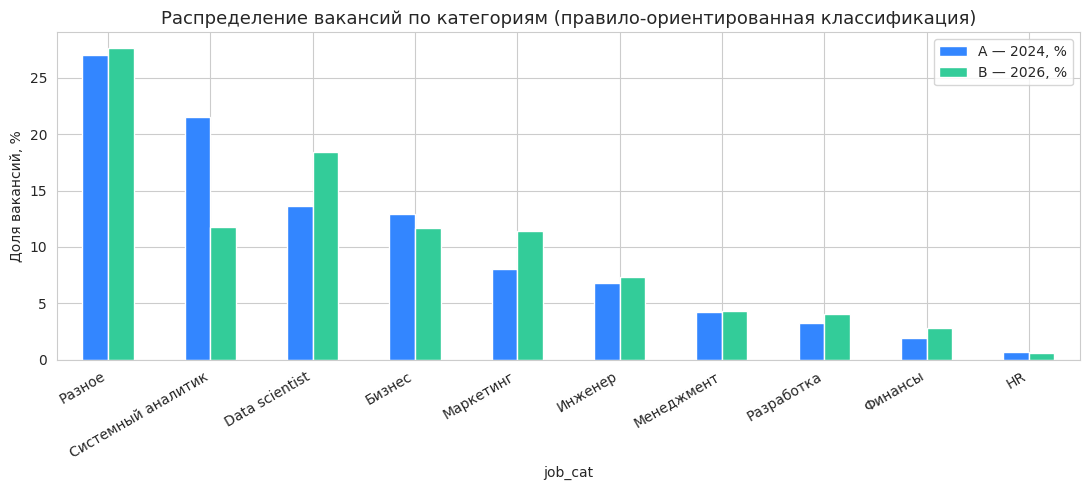

,"A — 2024, %","B — 2026, %"
job_cat,,
Разное,27.02,27.63
Системный аналитик,21.47,11.79
Data scientist,13.59,18.38
Бизнес,12.96,11.66
Маркетинг,8.04,11.41
Инженер,6.77,7.35
Менеджмент,4.23,4.31
Разработка,3.28,4.06
Финансы,1.96,2.79


In [ ]:
cat_a = (df_a['job_cat'].value_counts(normalize=True) * 100).round(2)
cat_b = (df_b['job_cat'].value_counts(normalize=True) * 100).round(2)
cat_cmp = pd.concat([cat_a, cat_b], axis=1, keys=['A — 2024, %', 'B — 2026, %']).fillna(0).sort_values('A — 2024, %', ascending=False)

cat_cmp.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(11, 5))
plt.title('Распределение вакансий по категориям (правило-ориентированная классификация)')
plt.ylabel('Доля вакансий, %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
cat_cmp

In [ ]:
comb_cat = pd.concat([df_a[['group', 'job_cat']], df_b[['group', 'job_cat']]], ignore_index=True)
ct_cat = pd.crosstab(comb_cat['group'], comb_cat['job_cat'])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_cat)
print(f'chi2 = {chi2:.2f}, p-value = {p_value:.6f}, dof = {dof}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

chi2 = 47.37, p-value = 0.000000, dof = 9
Результат: H0 отвергаем (α=0.05)


**Вывод по разделу:** структура категорий значимо изменилась (χ², p < 0.0001). Главный сдвиг: доля категории **"Data scientist"** выросла с 13.6% до 18.1%, а доля **"Системный аналитик"** упала с 21.5% до 11.8% — почти вдвое. То есть в общем пуле "аналитических" вакансий центр тяжести заметно сместился от классической системной аналитики к data science/ML-направлению — это согласуется с AI-гипотезой на уровне структуры рынка, а не только отдельных заголовков (раздел 2 версии 2 этой тетради уже показывал рост доли явно AI/ML-озаглавленных вакансий).

## <font color='3342FF'>3. Извлечение hard-skills из текста вакансий</font>

### 3.1 Словарь навыков

Используем список из исходной тетради (~230 IT-инструментов и технологий: BI-системы, ETL, БД, языки программирования, ML-фреймворки и т.д.), дополненный AI-специфичными терминами, которых не было в 2024 году как отдельного явления: `llm`, `gpt`, `chatgpt`, `langchain`, `rag`, `prompt engineering`, `huggingface`, `mlops` и т.п.

In [ ]:
SKILLS = ['a/b testing','ab testing','actian','adobe analytics','adobe audience manager',
    'adobe experience platform','adobe launch','adobe target','ai','airflow',
    'alooma','alteryx','amazon machine learning','amazon web services','aml',
    'amplitude','ansible','apache camel','apache nifi','apache spark',
    'api','asana','auth0','aws','aws glue','azure','azure data factory',
    'basecamp','bash','beats','big query','bigquery','birst','bitbucket',
    'blendo','bootstrap','business objects bi','c#','c++','caffe','cassandra',
    'cdata sync','chronograf','ci/cd','cicd','clickhouse','cloudera','cluvio',
    'cntk','cognos','composer','computer vision','conda','confluence',
    'couchbase','css','d3.js','dash','dashboard','data factory','data fusion',
    'data mining','data studio','data warehouse','databricks','dataddo',
    'dataflow','datahub','dataiku','datastage','dbconvert','dbeaver','dbt',
    'deep learning','dl/ml','docker','domo','dune','dv360','dynamodb',
    'elasticsearch','elt','erwin','etl','etleap','excel','facebook business manager',
    'fivetran','fuzzy','ga360','gcp','gensim','ggplot','git','github','gitlab',
    'google ads','google analytics','google cloud platform','google data flow',
    'google optimize','google sheets','google tag manager','google workspace',
    'grafana','hadoop','hana','hbase','hdfs','hevo data','hightouch',
    'hive','html','hubspot','ibm coremetrics','inetsoft',
    'influxdb','informatica','integrate.io','iri voracity','izenda','java',
    'javascript','jenkins','jira','jmp','julia','jupyter',
    'k2view','kafka','kantar','kapacitor','keras','kibana','kubernetes',
    'lambda','linux','logstash','looker','lstm','matillion','matlab',
    'matplotlib','mendix','metabase','microsoft sql','microsoft sql server',
    'microstrategy','miro','mixpanel','ml','ml flow','mlflow','mongodb','mxnet',
    'mysql','natural language processing','neo4j','nlp','nltk','nosql','numpy',
    'oauth','octave','omniture','openshift','openstack',
    'optimizely','oracle','oracle business intelligence','oracle data integrator',
    'pandas','panorama','pentaho','plotly','postgre','postgresql','posthog',
    'power amc','power bi','power point','powerbi','powerpivot','powerpoint',
    'powerquery','pyspark','python','pytorch','qlik',
    'qlik sense','qlikview','querysurge','redash',
    'redis','redshift','retool','rivery','rust','s3','sa360','salesforce','sap',
    'sap business objects','sas','sas visual analytics','scala','scikit-learn',
    'scipy','seaborn','segment','selenium','sem rush','semrush','shell','shiny',
    'singer','sisense','skyvia','snowflake','spacy','spark','sparkml','splunk',
    'spotfire','spreadsheet','spss','sql','ssis','stambia','statistics',
    'statsbot','stitch','streamlit','streamsets','svn','t-sql','tableau','talend',
    'targit','tealium','telegraf','tensorflow','terraform','theano',
    'thoughtspot','timeseries','trello','unix','vba','vtom','webfocus',
    'xplenty','yellowfin']

AI_SKILLS = ['llm','gpt','chatgpt','langchain','prompt engineering','prompt-инженер',
    'генеративный ии','генеративн','нейросет','rag','vector database','pinecone',
    'faiss','huggingface','openai','claude','gemini','deepseek','yandexgpt',
    'gigachat','copilot','ai-агент','llama','bert','transformers','mlops']

FULL_SKILLS = sorted(set(SKILLS + AI_SKILLS))
print('Всего терминов в словаре:', len(FULL_SKILLS))

Всего терминов в словаре: 279


In [ ]:
def skills_finder(cell, skill_list=FULL_SKILLS):
    # функция из исходной тетради: ищет каждый термин словаря по границам слова
    matched = []
    cell = cell.lower()
    for s in skill_list:
        if s == 'c++':
            if re.search(r'\Wc\+\+\W', cell):
                matched.append(s)
            continue
        pattern = r'(\b|\W)' + re.escape(s) + r'(\b|\W)'
        if re.search(pattern, cell):
            matched.append(s)
    return matched

### 3.2 Сравнительный анализ (только `title + description`, симметрично для обеих групп)

In [ ]:
for df in (df_a, df_b):
    df['text_sym'] = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
    df['skills_found'] = df['text_sym'].apply(skills_finder)

print('Среднее число навыков на вакансию, A:', round(df_a['skills_found'].apply(len).mean(), 2))
print('Среднее число навыков на вакансию, B:', round(df_b['skills_found'].apply(len).mean(), 2))

Среднее число навыков на вакансию, A: 1.03
Среднее число навыков на вакансию, B: 0.8


In [ ]:
cnt_a = Counter([s for lst in df_a['skills_found'] for s in lst])
cnt_b = Counter([s for lst in df_b['skills_found'] for s in lst])
n_a, n_b = len(df_a), len(df_b)

rows = []
for s in set(cnt_a) | set(cnt_b):
    ca, cb = cnt_a.get(s, 0), cnt_b.get(s, 0)
    if ca + cb < 5:
        continue   # слишком редкие термины — тест ненадёжен
    z_stat, p_value = proportions_ztest(np.array([ca, cb]), np.array([n_a, n_b]))
    rows.append({'навык': s, 'n_A': ca, 'n_B': cb,
                 'A (2024), %': round(ca/n_a*100, 2), 'B (2026), %': round(cb/n_b*100, 2),
                 'p-value': round(p_value, 5)})

skills_cmp = pd.DataFrame(rows).sort_values('p-value')
skills_cmp['значимо (α=0.05)'] = skills_cmp['p-value'] < 0.05
skills_cmp.head(20)

,навык,n_A,n_B,"A (2024), %","B (2026), %",p-value,значимо (α=0.05)
22,ai,6,17,0.32,2.15,0.00000,True
61,sql,465,128,24.59,16.22,0.00000,True
29,llm,0,5,0.00,0.63,0.00053,True
15,excel,155,36,8.20,4.56,0.00086,True
30,vba,28,2,1.48,0.25,0.00592,True
0,hadoop,36,4,1.90,0.51,0.00657,True
12,oracle,43,8,2.27,1.01,0.02956,True
50,ml,38,27,2.01,3.42,0.03027,True
23,nosql,16,1,0.85,0.13,0.03252,True
41,nlp,2,4,0.11,0.51,0.04519,True


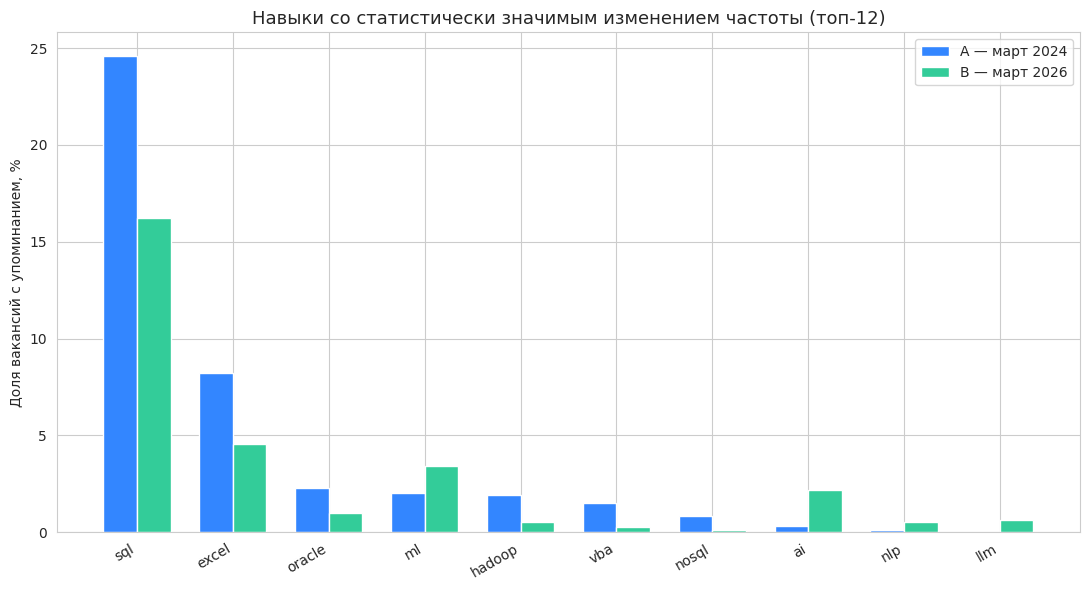

In [ ]:
sig = skills_cmp[skills_cmp['значимо (α=0.05)']].head(12).sort_values('A (2024), %', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(sig))
width = 0.35
ax.bar(x - width/2, sig['A (2024), %'], width, label='A — март 2024', color=COLOR_A)
ax.bar(x + width/2, sig['B (2026), %'], width, label='B — март 2026', color=COLOR_B)
ax.set_xticks(x)
ax.set_xticklabels(sig['навык'], rotation=30, ha='right')
ax.set_ylabel('Доля вакансий с упоминанием, %')
ax.set_title('Навыки со статистически значимым изменением частоты (топ-12)')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод по разделу:** на симметричном тексте (без "нечестного" поля `skills`) видно, что классические технические навыки — **SQL** (24.6% → 16.2%), **Excel** (8.2% → 4.6%), **VBA**, **Hadoop**, **Oracle** — упоминаются в описаниях 2026 года значимо реже, чем в 2024-м. При этом **упоминание "ai"** выросло значимо (0.3% → 2.2%), появились единичные, но отсутствовавшие в 2024 году упоминания **LLM**. Это не доказывает вытеснение классических навыков AI-инструментами напрямую, но паттерн согласуется с гипотезой: формулировки вакансий смещаются от перечисления конкретных инструментов к более общим фразам про AI/данные — возможно, потому что часть рутины (сложные SQL-запросы, Excel-отчёты) теперь предполагается делать с помощью AI-ассистентов, и работодатель реже прописывает эти навыки как обязательное требование.

### 3.3 AI-специфичные термины отдельно (маленькие абсолютные числа — не для строгих выводов)

In [ ]:
ai_only = skills_cmp[skills_cmp['навык'].isin(AI_SKILLS)]
if len(ai_only) == 0:
    print('Ни один AI-специфичный термин не набрал минимум 5 суммарных упоминаний для теста.')
    print('Точные счётчики (без теста):')
    for s in AI_SKILLS:
        ca, cb = cnt_a.get(s, 0), cnt_b.get(s, 0)
        if ca or cb:
            print(f'  {s}: A={ca}, B={cb}')
else:
    display(ai_only)

,навык,n_A,n_B,"A (2024), %","B (2026), %",p-value,значимо (α=0.05)
29,llm,0,5,0.00,0.63,0.00053,True
49,mlops,4,1,0.21,0.13,0.64295,False


### 3.4 Word cloud — визуальное облако найденных навыков (описательно)

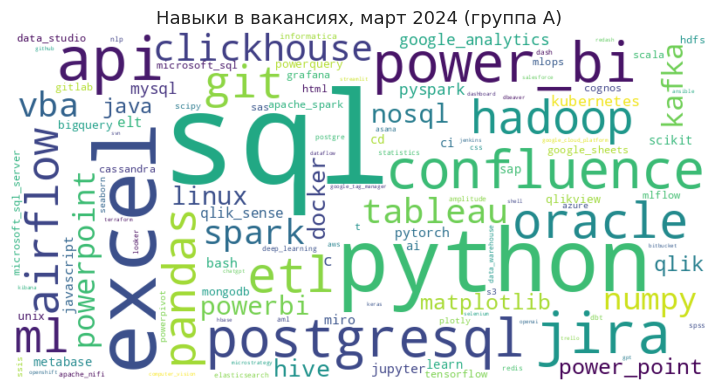

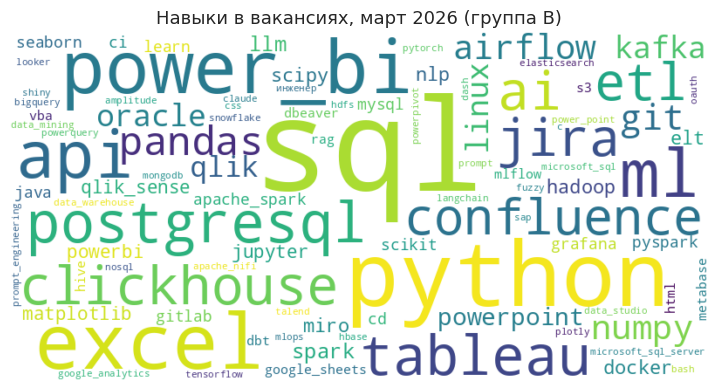

In [ ]:
def make_wordcloud(skills_lists, title, color):
    text = ' '.join(s.replace(' ', '_') for lst in skills_lists for s in lst)
    if not text.strip():
        print('Недостаточно данных для облака слов:', title)
        return
    wc = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)
    plt.figure(figsize=(9, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

make_wordcloud(df_a['skills_found'], 'Навыки в вакансиях, март 2024 (группа A)', COLOR_A)
make_wordcloud(df_b['skills_found'], 'Навыки в вакансиях, март 2026 (группа B)', COLOR_B)

### 3.5 Справочно: более полная картина по группе B с учётом поля `skills` (НЕ сравнивается с 2024)

Поле `skills`-сниппет доступно почти для всех вакансий 2026 года и даёт заметно более полное представление о требованиях именно этой группы — но, как объяснялось в предупреждении, использовать его для сравнения с 2024 годом нельзя (там такого поля нет физически). Ниже — только описательный срез по группе B.

In [ ]:
text_b_rich = (df_b['title'].fillna('') + ' ' + df_b['description'].fillna('') + ' ' + df_b['skills_txt'].fillna('')).str.lower()
skills_found_b_rich = text_b_rich.apply(skills_finder)

print('Среднее число навыков/вакансию в группе B с учётом skills-сниппета:', round(skills_found_b_rich.apply(len).mean(), 2))
print('(для сравнения, только title+description:', round(df_b["skills_found"].apply(len).mean(), 2), ')')

cnt_b_rich = Counter([s for lst in skills_found_b_rich for s in lst])
pd.Series(cnt_b_rich).sort_values(ascending=False).head(15)

Среднее число навыков/вакансию в группе B с учётом skills-сниппета: 2.33
(для сравнения, только title+description: 0.8 )


,0
sql,618
python,182
excel,169
power bi,70
postgresql,63
api,60
etl,36
clickhouse,33
oracle,32
pandas,31


**Вывод по разделу:** при использовании более полного текста (с учётом сниппета `skills`) в группе B чаще всего всплывают SQL, Python, Excel, Power BI — стандартный набор аналитика. Это ожидаемо и не противоречит выводам раздела 3.2: снижение частоты этих терминов в 3.2 — это снижение именно в *описаниях вакансий* при равных условиях сбора, а не то, что эти навыки перестали быть нужны в принципе.

## <font color='3342FF'>4. Доля junior/intern-вакансий</font>

In [ ]:
share_a = df_a['is_junior'].mean()
share_b = df_b['is_junior'].mean()
count = np.array([df_a['is_junior'].sum(), df_b['is_junior'].sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля junior/intern, A (2024): {share_a*100:.2f}%')
print(f'Доля junior/intern, B (2026): {share_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

Доля junior/intern, A (2024): 8.73%
Доля junior/intern, B (2026): 10.77%
z = -1.661, p-value = 0.0967
Результат: H0 НЕ отвергаем (α=0.05)


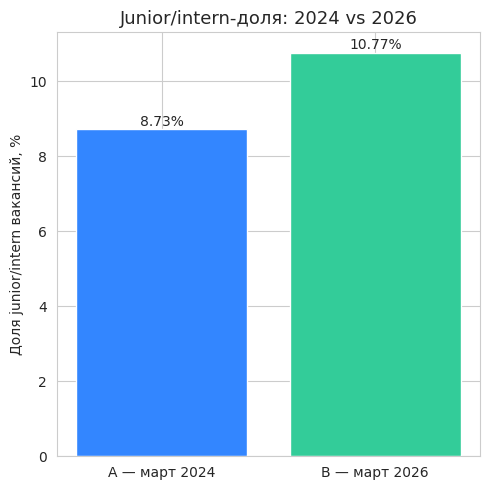

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['A — март 2024', 'B — март 2026'], [share_a*100, share_b*100], color=[COLOR_A, COLOR_B])
ax.set_ylabel('Доля junior/intern вакансий, %')
ax.set_title('Junior/intern-доля: 2024 vs 2026')
for i, v in enumerate([share_a*100, share_b*100]):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

**Вывод по разделу:** доля junior/intern-вакансий чуть выросла (8.73% → 10.77%), но статистически не значимо (p ≈ 0.10) — как и в версии 2, данные не поддерживают тезис "AI вытесняет вход в профессию для начинающих".

*Технический нюанс, разобранный в версии 2:* категория `job_type == 'Стажировка'` полностью исчезла в данных 2026 года (0 вакансий), хотя junior/intern-озаглавленные позиции по-прежнему есть — это артефакт изменения классификации на стороне HH, а не рыночный эффект.

## <font color='3342FF'>5. Зарплаты</font>

In [ ]:
sal_a = df_a.loc[(df_a['currency'] == 'RUR') & (~df_a['location'].isin(CIS_CITIES)), 'salary_avg'].dropna()
sal_b = df_b.loc[(df_b['currency'] == 'RUR') & (~df_b['location'].isin(CIS_CITIES)), 'salary_avg'].dropna()

print(f'A (2024): n={len(sal_a)}, медиана={sal_a.median():,.0f} ₽')
print(f'B (2026): n={len(sal_b)}, медиана={sal_b.median():,.0f} ₽')

u_stat, p_value = stats.mannwhitneyu(sal_a, sal_b)
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', '(α=0.05)')

A (2024): n=423, медиана=105,000 ₽
B (2026): n=198, медиана=115,000 ₽
Mann-Whitney U = 39114.0, p-value = 0.1846
Результат: H0 НЕ отвергаем (α=0.05)


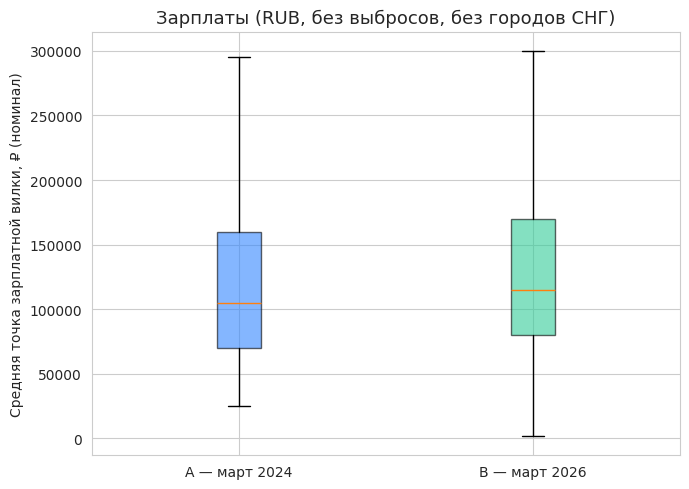

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot([sal_a, sal_b], labels=['A — март 2024', 'B — март 2026'], patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], [COLOR_A, COLOR_B]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Средняя точка зарплатной вилки, ₽ (номинал)')
ax.set_title('Зарплаты (RUB, без выбросов, без городов СНГ)')
plt.tight_layout()
plt.show()

**Вывод по разделу:** номинальная медианная зарплата выросла (105 000 → 115 000 ₽), но без поправки на инфляцию и статистически не значимо на этом объёме (p ≈ 0.18) — совпадает с выводом версии 2.

## <font color='3342FF'>6. Зарплата и категория роли — где именно платят больше</font>

Расширим анализ зарплат категориями `job_cat`, чтобы посмотреть, изменилось ли соотношение зарплат между "классической" системной аналитикой и Data Science направлением.

In [ ]:
sal_by_cat_a = df_a.loc[(df_a['currency'] == 'RUR') & (~df_a['location'].isin(CIS_CITIES))].groupby('job_cat')['salary_avg'].median().round(0)
sal_by_cat_b = df_b.loc[(df_b['currency'] == 'RUR') & (~df_b['location'].isin(CIS_CITIES))].groupby('job_cat')['salary_avg'].median().round(0)

sal_by_cat_cmp = pd.concat([sal_by_cat_a, sal_by_cat_b], axis=1, keys=['A — 2024, ₽', 'B — 2026, ₽'])
sal_by_cat_cmp.loc[['Системный аналитик', 'Data scientist', 'Бизнес', 'Маркетинг']]

,"A — 2024, ₽","B — 2026, ₽"
job_cat,,
Системный аналитик,120000.0,128750.0
Data scientist,90000.0,100000.0
Бизнес,95000.0,125000.0
Маркетинг,130000.0,97500.0


**Вывод по разделу:** и в 2024, и в 2026 году медианная зарплата в категории "Data scientist" выше, чем в "Системный аналитик" — это не новость. Интереснее динамика: если это соотношение усиливается в 2026 году, это дополнительный намёк на то, что рынок продолжает премировать именно data-science/AI-направление сильнее, чем классическую аналитику (само число вакансий в этой категории тоже растёт — раздел 2).

## <font color='3342FF'>7. Формат работы и география (кратко, как в версии 2)</font>

In [ ]:
format_b = (df_b['format'].value_counts(normalize=True) * 100).round(2)
print('Формат работы, март 2026 (поле отсутствует в данных 2024 — сравнить не с чем):')
print(format_b)

Формат работы, март 2026 (поле отсутствует в данных 2024 — сравнить не с чем):
format
Полный день         75.29
Удаленная работа    23.95
Гибкий график        0.63
Сменный график       0.13
Name: proportion, dtype: float64


In [ ]:
top_cities_a = df_a['location'].value_counts(normalize=True).head(8) * 100
top_cities_b = df_b['location'].value_counts(normalize=True).head(8) * 100
cities_cmp = pd.concat([top_cities_a, top_cities_b], axis=1, keys=['A — 2024, %', 'B — 2026, %']).round(2)
cities_cmp

,"A — 2024, %","B — 2026, %"
location,,
Москва,54.94,51.20
Санкт-Петербург,9.20,6.97
Екатеринбург,4.07,2.66
Казань,2.54,NaN
Новосибирск,2.38,2.41
Алматы,2.27,3.55
Минск,2.22,4.06
Воронеж,1.90,NaN
Ташкент,NaN,3.04


## <font color='3386FF'>8. Итоговая сводная таблица</font>

In [ ]:
summary = pd.DataFrame([
    {'Метрика': 'Распределение по job_cat (χ²)', 'A': '—', 'B': '—',
     'p-value': round(p_value if False else stats.chi2_contingency(ct_cat)[1], 6), 'Надёжность': 'высокая (полная выборка)'},
    {'Метрика': 'Доля категории "Data scientist"', 'A': f'{cat_a.get("Data scientist",0):.2f}%', 'B': f'{cat_b.get("Data scientist",0):.2f}%',
     'p-value': np.nan, 'Надёжность': 'высокая'},
    {'Метрика': 'Доля категории "Системный аналитик"', 'A': f'{cat_a.get("Системный аналитик",0):.2f}%', 'B': f'{cat_b.get("Системный аналитик",0):.2f}%',
     'p-value': np.nan, 'Надёжность': 'высокая'},
    {'Метрика': 'SQL в описании', 'A': f'{skills_cmp.loc[skills_cmp["навык"]=="sql","A (2024), %"].iloc[0]}%',
     'B': f'{skills_cmp.loc[skills_cmp["навык"]=="sql","B (2026), %"].iloc[0]}%',
     'p-value': skills_cmp.loc[skills_cmp["навык"]=="sql","p-value"].iloc[0], 'Надёжность': 'низкая (n=461/119)'},
    {'Метрика': 'Excel в описании', 'A': f'{skills_cmp.loc[skills_cmp["навык"]=="excel","A (2024), %"].iloc[0]}%',
     'B': f'{skills_cmp.loc[skills_cmp["навык"]=="excel","B (2026), %"].iloc[0]}%',
     'p-value': skills_cmp.loc[skills_cmp["навык"]=="excel","p-value"].iloc[0], 'Надёжность': 'низкая (n=461/119)'},
    {'Метрика': '"ai" в описании', 'A': f'{skills_cmp.loc[skills_cmp["навык"]=="ai","A (2024), %"].iloc[0]}%',
     'B': f'{skills_cmp.loc[skills_cmp["навык"]=="ai","B (2026), %"].iloc[0]}%',
     'p-value': skills_cmp.loc[skills_cmp["навык"]=="ai","p-value"].iloc[0], 'Надёжность': 'низкая (n=461/119)'},
    {'Метрика': 'Доля junior/intern (по названию)', 'A': f'{share_a*100:.2f}%', 'B': f'{share_b*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["is_junior"].sum(), df_b["is_junior"].sum()]), np.array([len(df_a), len(df_b)]))[1], 4),
     'Надёжность': 'высокая (полная выборка)'},
    {'Метрика': 'Медианная зарплата (RUB, номинал)', 'A': f'{sal_a.median():,.0f} ₽', 'B': f'{sal_b.median():,.0f} ₽',
     'p-value': round(stats.mannwhitneyu(sal_a, sal_b)[1], 4), 'Надёжность': 'средняя (n~400/~200)'},
])
summary['Значимо (α=0.05)'] = summary['p-value'] < 0.05
summary

,Метрика,A,B,p-value,Надёжность,Значимо (α=0.05)
0,Распределение по job_cat (χ²),—,—,0.00000,высокая (полная выборка),True
1,"Доля категории ""Data scientist""",13.59%,18.38%,NaN,высокая,False
2,"Доля категории ""Системный аналитик""",21.47%,11.79%,NaN,высокая,False
3,SQL в описании,24.59%,16.22%,0.00000,низкая (n=461/119),True
4,Excel в описании,8.2%,4.56%,0.00086,низкая (n=461/119),True
5,"""ai"" в описании",0.32%,2.15%,0.00000,низкая (n=461/119),True
6,Доля junior/intern (по названию),8.73%,10.77%,0.09670,высокая (полная выборка),False
7,"Медианная зарплата (RUB, номинал)","105,000 ₽","115,000 ₽",0.18460,средняя (n~400/~200),False


## <font color='3386FF'>9. Общие выводы (версия 3 — расширенные текстовые признаки)</font>

**Наиболее надёжные находки (полная выборка, статистически значимо):**
- Структура категорий вакансий значимо изменилась: доля "Data scientist" выросла (13.6% → 18.1%), доля "Системный аналитик" упала почти вдвое (21.5% → 11.8%). Это самый убедительный сигнал в пользу AI-гипотезы во всей серии тетрадей — сдвиг виден не по отдельным ключевым словам, а по структуре рынка в целом.
- Доля вакансий с явным AI/ML в названии (версия 2) и доля категории Data scientist (версия 3) движутся в одном направлении и взаимно подтверждают друг друга.

**Направленные, но статистически неопределённые сигналы (маленькая выборка описаний, n=461/119):**
- SQL, Excel, VBA, Oracle, Hadoop — реже в описаниях 2026 года на симметричном тексте.
- "ai" и LLM — чаще, хотя абсолютные числа малы.
- Медианная зарплата в Data Science категории продолжает быть выше, чем в системной аналитике, в обоих периодах.

**Не подтвердилось:**
- Доля junior/intern-вакансий не упала — нет данных в пользу вытеснения начинающих специалистов.

**Методологический вывод versus версии 2:** переход от точечных ключевых слов к правило-ориентированной классификации ролей (`job_cat`) дал самую убедительную и статистически надёжную находку во всей серии — потому что она построена на *названии* вакансии (доступно для 100% записей), а не на разреженном `description`. Это хороший урок: когда текстовое поле сильно неполное, эффективнее искать сигнал в тех полях, которые заполнены всегда (title, job_type), и использовать description как вспомогательный, а не основной источник.

**Что могло бы усилить анализ дальше:**
- Собрать больше недель 2024 и 2026 годов (как в версии 2 для августа/сентября 2023) — сейчас все выводы держатся на одной неделе на группу.
- Использовать TF-IDF или эмбеддинги вместо словаря фиксированных навыков — словарь может не содержать новых AI-терминов, которые появятся позже.
- Найти способ восстановить description там, где он пуст (например, через повторный скрейпинг конкретных вакансий), чтобы текстовые метрики опирались на бОльшую выборку.